<a href="https://colab.research.google.com/github/nuraini2502/MachineLearning/blob/Praktikum5/praktikumMandiri.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Praktikum 5 - Machine Learning Decision Tree


Nama : Nuraini

NIM : 0110222170

Matkul : Machine Learning | Sesi Pagi

In [1]:
# import library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# Menghubungkan colab dengan google drive
from google.colab import drive
drive.mount('/content/gdrive')

# Memanggil dataset melalui gdrive
path = "gdrive/MyDrive/MachineLearning/Praktikum/data/week5/"

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


# 1. Gunakan dataset Iris untuk klasifikasi dengan target nama species

In [3]:
df = pd.read_csv(path + "Iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
# Load dataset Iris
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print("=== 5 Data Teratas ===")
print(df.head())
print("\n=== Informasi Dataset ===")
print(df.info())

=== 5 Data Teratas ===
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  

=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   specie

# Buat model Decision Tree, bagi data menjadi 80% data training dan 20% data testing

In [5]:
# Membagi dataset
X = df.drop(['species'], axis=1)
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
len(X_train), len(X_test)

(120, 30)

In [6]:
# Membangun model
dt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    random_state=42
)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

# Melakukan evaluasi model yang dibuat

In [7]:
# Evaluasi
y_pred = dt.predict(X_test)

print("Akurasi:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(
    y_test, y_pred))

Akurasi: 93.33 %

Confusion Matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



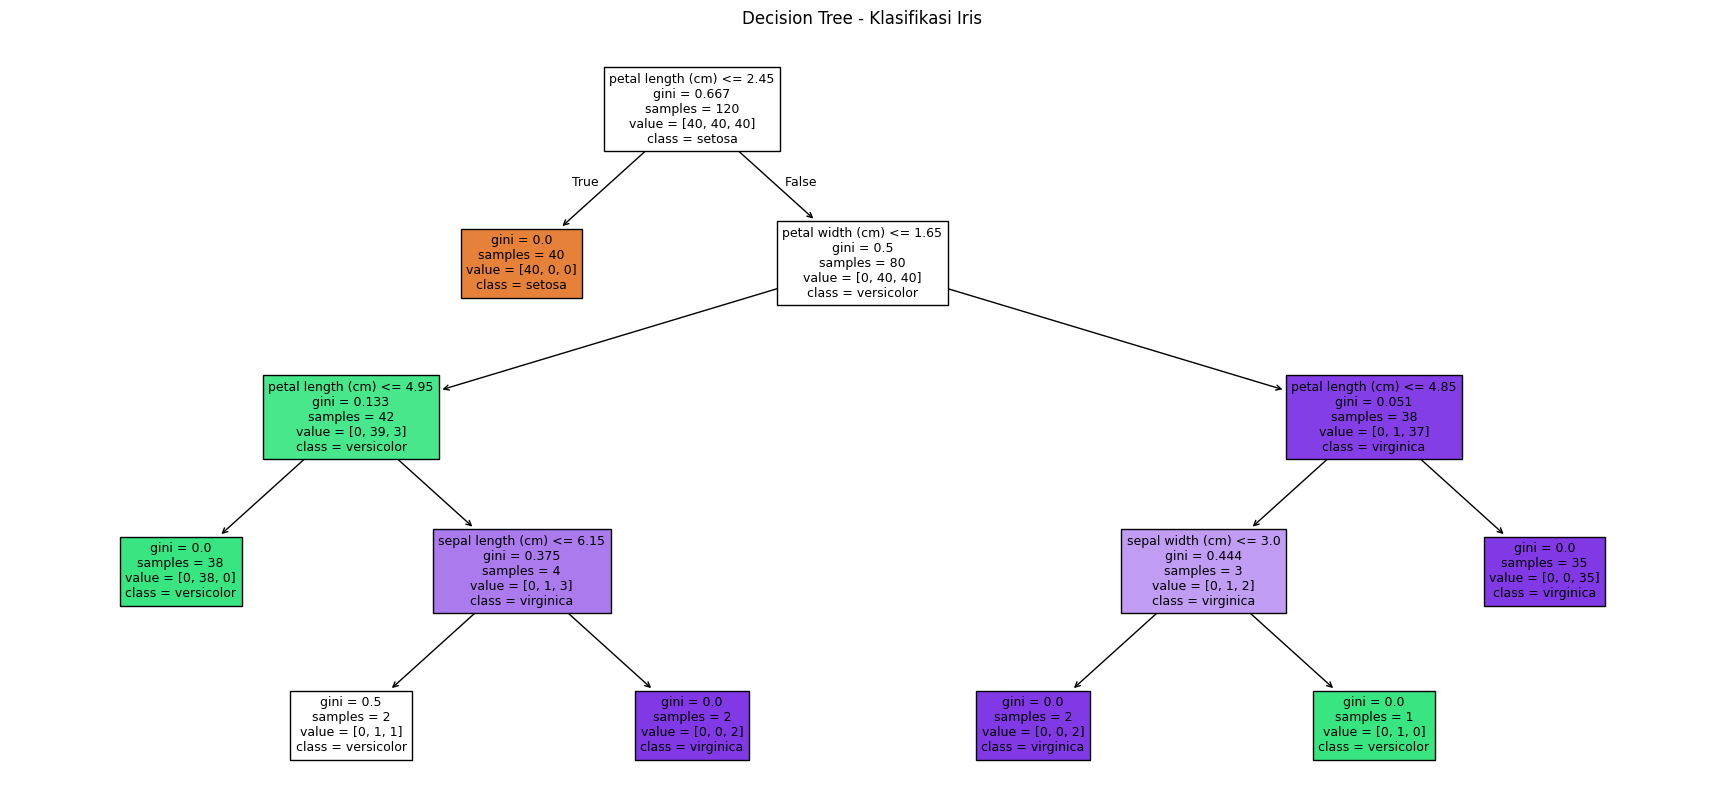

In [8]:
# Visualisasi model
plt.figure(figsize=(22, 10))
plot_tree(
    dt,
    feature_names=X.columns.tolist(),
    class_names=y.unique(),
    filled=True,
    fontsize=9
)
plt.title("Decision Tree - Klasifikasi Iris")
plt.show()

# Menguji model menggunakan dataset testing

In [9]:
# Pengujian Model Menggunakan Data Testing
hasil = pd.DataFrame({
    "Data Aktual": y_test,
    "Data Prediksi": y_pred
})
print("\n=== Hasil Prediksi pada Data Testing ===")
print(hasil.head(10))


=== Hasil Prediksi pada Data Testing ===
    Data Aktual Data Prediksi
38       setosa        setosa
127   virginica     virginica
57   versicolor    versicolor
93   versicolor    versicolor
42       setosa        setosa
56   versicolor    versicolor
22       setosa        setosa
20       setosa        setosa
147   virginica     virginica
84   versicolor    versicolor
